# EDA — Datos de Mercado (Magnificent 7)

**Input:** `data/clean/dataset_integrado.csv`  
**Período:** 2019-01-03 → 2025-12-30  
**Empresas:** AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA  

Este notebook cubre el análisis descriptivo completo de los datos de mercado:
estadísticas descriptivas, distribución de retornos, volatilidad, descomposición STL,
normalidad y correlaciones entre empresas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Rutas
BASE_DIR   = Path('..').resolve()
FIGURAS    = BASE_DIR / 'docs' / 'figuras'
FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta consistente para las 7 empresas
TICKERS  = ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
COLORES  = dict(zip(TICKERS, sns.color_palette('tab10', 7)))

# Estilo global
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
})

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga del dataset

In [2]:
df = pd.read_csv(BASE_DIR / 'data' / 'clean' / 'dataset_integrado.csv', parse_dates=['date'])

print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Período: {df.date.min().date()} → {df.date.max().date()}')
print(f'Empresas: {sorted(df.ticker.unique())}')
print(f'Días por empresa: {df.groupby("ticker").size().iloc[0]}')
df.dtypes

Shape: 12,754 filas × 39 columnas
Período: 2019-01-03 → 2026-04-02
Empresas: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Días por empresa: 1822


date                       datetime64[ns]
ticker                             object
open                              float64
high                              float64
low                               float64
close                             float64
volume                              int64
log_return                        float64
vol_realized_5d                   float64
vol_realized_20d                  float64
vol_intraday                      float64
abs_return                        float64
sq_return                         float64
log_volume_change                 float64
news_tone_mean                    float64
news_tone_std                     float64
news_tone_median                  float64
news_tone_min                     float64
news_tone_max                     float64
news_n_noticias                   float64
news_pct_negativo                 float64
news_pct_positivo                 float64
rddt_n_posts                      float64
rddt_score_mean                   

## 2. Estadísticas descriptivas por empresa

Se calculan las métricas de tendencia central y dispersión para las variables de mercado
más relevantes: retornos logarítmicos, volatilidad realizada a 20 días (variable objetivo)
y volatilidad intradiaria. Se incluyen asimetría (skewness) y curtosis (kurtosis) porque
las distribuciones financieras típicamente exhiben colas gruesas — un supuesto clave para
la validación de los modelos GARCH.

In [3]:
# ── Tabla de estadísticas descriptivas ──
filas = []
for t in TICKERS:
    s = df[df.ticker == t]
    r = s['log_return'].dropna()
    v = s['vol_realized_20d'].dropna()
    filas.append({
        'Empresa'        : t,
        'Ret. medio (%)'  : round(r.mean() * 100, 3),
        'Ret. std (%)'    : round(r.std()  * 100, 3),
        'Ret. min (%)'    : round(r.min()  * 100, 2),
        'Ret. max (%)'    : round(r.max()  * 100, 2),
        'Skewness'        : round(stats.skew(r), 3),
        'Kurtosis'        : round(stats.kurtosis(r), 3),
        'Vol20d media'    : round(v.mean(), 4),
        'Vol20d std'      : round(v.std(),  4),
        'Vol20d max'      : round(v.max(),  4),
    })

tabla = pd.DataFrame(filas).set_index('Empresa')
display(tabla)

print('\nNotas interpretativas:')
print('  Skewness < 0 → distribución con cola izquierda más pesada (caídas extremas más frecuentes)')
print('  Kurtosis > 0 → distribución leptocúrtica (colas más gruesas que la normal)')
print('  Una kurtosis > 3 en retornos es la regla en mercados financieros (fat tails)')

,Ret. medio (%),Ret. std (%),Ret. min (%),Ret. max (%),Skewness,Kurtosis,Vol20d media,Vol20d std,Vol20d max
Empresa,,,,,,,,,
AAPL,0.105,1.943,-13.77,14.26,-0.081,6.606,0.2763,0.1356,1.0812
AMZN,0.055,2.145,-15.14,12.69,-0.080,4.504,0.3165,0.1280,0.7703
GOOGL,0.095,1.965,-12.37,9.73,-0.141,4.085,0.2915,0.1137,0.9017
META,0.080,2.658,-30.64,20.93,-0.990,22.444,0.3757,0.1938,1.2252
MSFT,0.075,1.800,-15.95,13.29,-0.278,8.122,0.2567,0.1299,1.1344
NVDA,0.217,3.206,-20.40,21.81,0.004,4.276,0.4739,0.1894,1.3969
TSLA,0.157,3.997,-23.65,20.45,-0.099,3.705,0.5904,0.2245,1.6149



Notas interpretativas:
  Skewness < 0 → distribución con cola izquierda más pesada (caídas extremas más frecuentes)
  Kurtosis > 0 → distribución leptocúrtica (colas más gruesas que la normal)
  Una kurtosis > 3 en retornos es la regla en mercados financieros (fat tails)


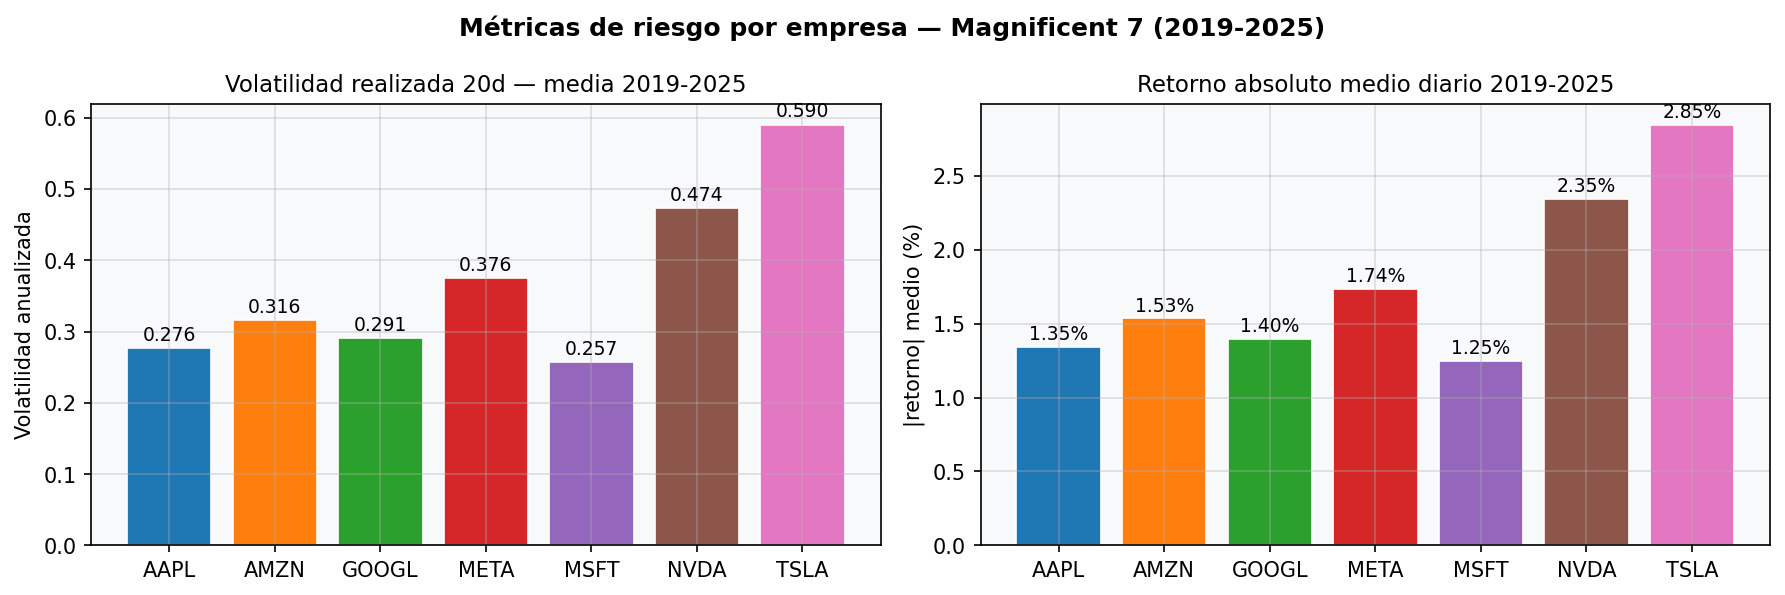

Guardado: eda_market_estadisticas.png


In [4]:
# ── Figura: estadísticas descriptivas de volatilidad ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vol_media  = [df[df.ticker == t]['vol_realized_20d'].mean() for t in TICKERS]
ret_abs    = [df[df.ticker == t]['abs_return'].mean() * 100 for t in TICKERS]
colores_v  = [COLORES[t] for t in TICKERS]

# Volatilidad 20d media
bars = axes[0].bar(TICKERS, vol_media, color=colores_v, edgecolor='white', linewidth=0.8)
axes[0].set_title('Volatilidad realizada 20d — media 2019-2025')
axes[0].set_ylabel('Volatilidad anualizada')
for b, v in zip(bars, vol_media):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Retorno absoluto medio
bars2 = axes[1].bar(TICKERS, ret_abs, color=colores_v, edgecolor='white', linewidth=0.8)
axes[1].set_title('Retorno absoluto medio diario 2019-2025')
axes[1].set_ylabel('|retorno| medio (%)')
for b, v in zip(bars2, ret_abs):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Métricas de riesgo por empresa — Magnificent 7 (2019-2025)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_estadisticas.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_estadisticas.png')

## 3. Boxplots de retornos logarítmicos

Los boxplots permiten visualizar la distribución de retornos y la presencia de outliers
extremos. Siguiendo la decisión metodológica del TFG, los outliers se conservan porque
representan los episodios de volatilidad extrema que son el objeto de estudio.

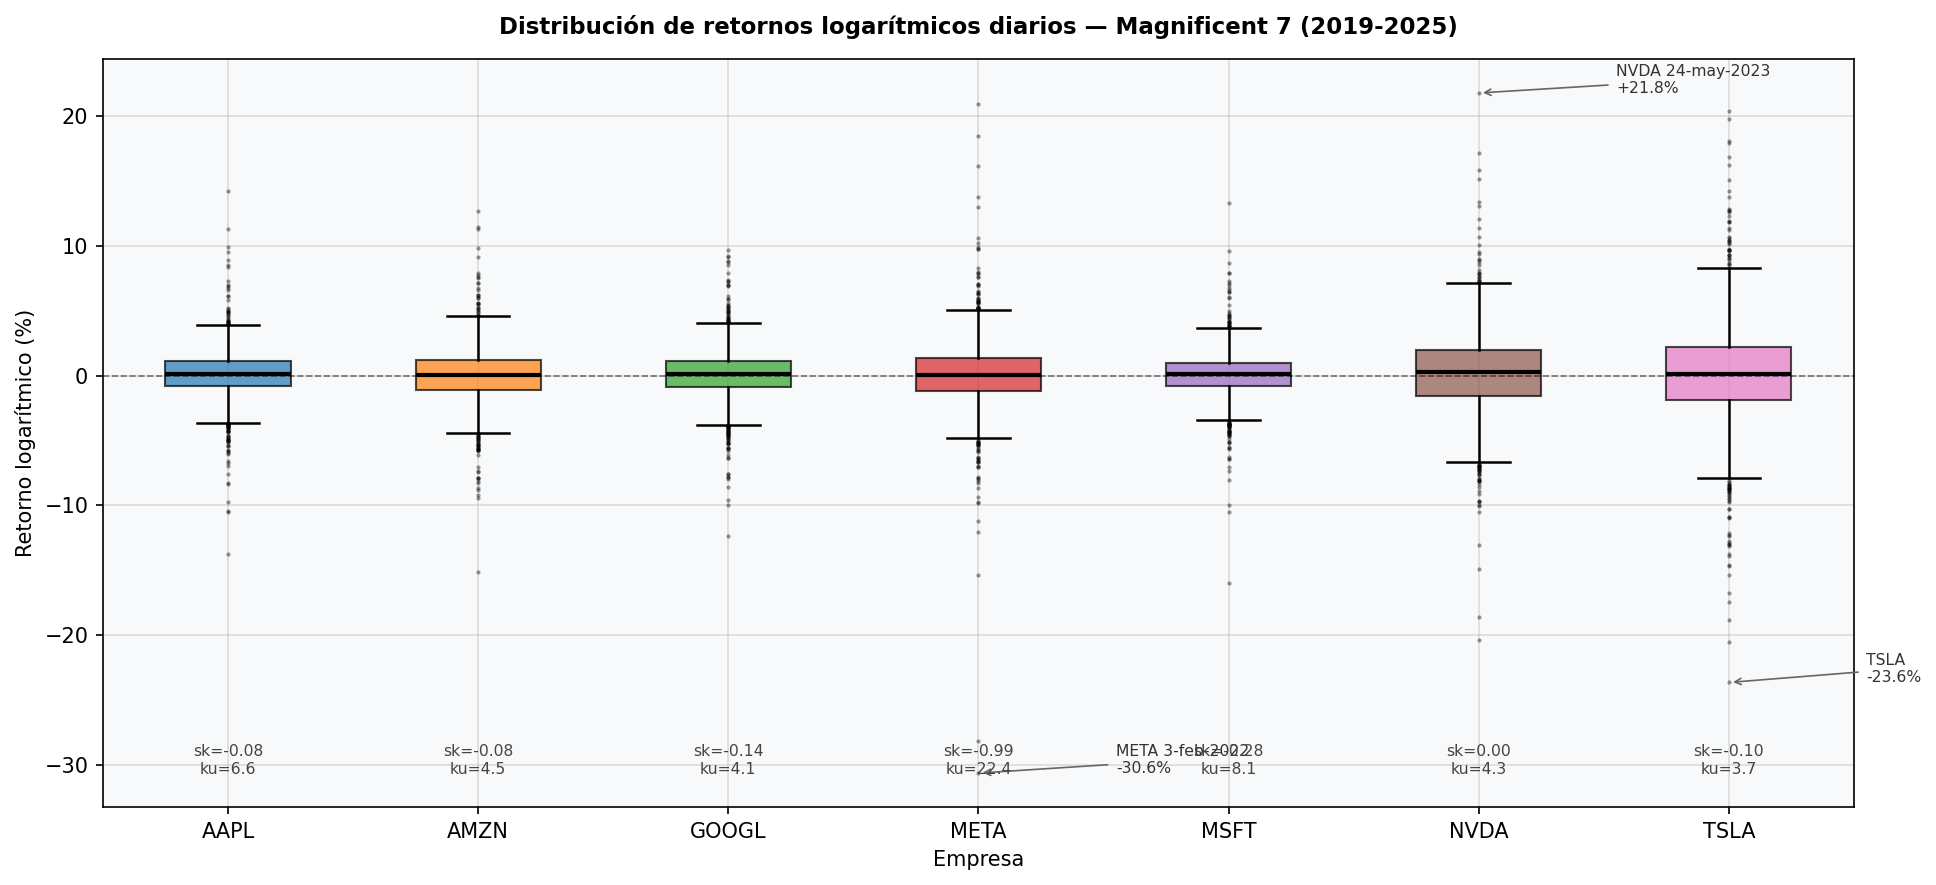

Guardado: eda_market_boxplot_retornos.png

Interpretación:
  - Todos los tickers muestran skewness negativa → caídas extremas más frecuentes que subidas extremas
  - Kurtosis >> 0 en todos (fat tails): la distribución normal subestima la frecuencia de eventos extremos
  - TSLA y NVDA tienen cajas más anchas = mayor dispersión habitual de retornos
  - META outlier inferior de -30.6%: caída del 3-feb-2022 por pérdida de usuarios activos


In [5]:
# ── Eventos históricos para anotar en los gráficos ──
EVENTOS = [
    {'fecha': '2020-03-16', 'label': 'COVID\nCrash',   'color': '#d62728', 'y': 0.40},
    {'fecha': '2021-01-27', 'label': 'GameStop\nWSB',  'color': '#ff7f0e', 'y': 0.55},
    {'fecha': '2022-02-03', 'label': 'META\n-30%',     'color': '#9467bd', 'y': 0.70},
    {'fecha': '2023-05-24', 'label': 'NVDA\nBoom IA',  'color': '#2ca02c', 'y': 0.85},
]

# ── Figura: Boxplot retornos logarítmicos ──
fig, ax = plt.subplots(figsize=(13, 6))

datos_box = [df[df.ticker == t]['log_return'].dropna() * 100 for t in TICKERS]

bp = ax.boxplot(
    datos_box,
    labels=TICKERS,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='.', markersize=2, alpha=0.4),
)

for patch, t in zip(bp['boxes'], TICKERS):
    patch.set_facecolor(COLORES[t])
    patch.set_alpha(0.7)

# Línea en 0
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Anotar outliers extremos relevantes
anotaciones = [
    # (ticker_idx_1based, retorno_aprox, texto)
    (4, -30.64, 'META 3-feb-2022\n-30.6%'),
    (6, +21.81, 'NVDA 24-may-2023\n+21.8%'),
    (7, -23.65, 'TSLA\n-23.6%'),
]
for idx, ret, txt in anotaciones:
    ax.annotate(txt, xy=(idx, ret), xytext=(idx + 0.55, ret),
                fontsize=7.5, color='#333333',
                arrowprops=dict(arrowstyle='->', color='#666666', lw=0.8))

ax.set_title('Distribución de retornos logarítmicos diarios — Magnificent 7 (2019-2025)',
             fontweight='bold', pad=12)
ax.set_ylabel('Retorno logarítmico (%)')
ax.set_xlabel('Empresa')

# Añadir skewness y kurtosis como texto en cada caja
for i, t in enumerate(TICKERS, 1):
    r = df[df.ticker == t]['log_return'].dropna()
    sk = stats.skew(r)
    ku = stats.kurtosis(r)
    ax.text(i, ax.get_ylim()[0] * 0.93,
            f'sk={sk:.2f}\nku={ku:.1f}',
            ha='center', va='bottom', fontsize=7.5, color='#444444')

plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_boxplot_retornos.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_boxplot_retornos.png')
print()
print('Interpretación:')
print('  - Todos los tickers muestran skewness negativa → caídas extremas más frecuentes que subidas extremas')
print('  - Kurtosis >> 0 en todos (fat tails): la distribución normal subestima la frecuencia de eventos extremos')
print('  - TSLA y NVDA tienen cajas más anchas = mayor dispersión habitual de retornos')
print('  - META outlier inferior de -30.6%: caída del 3-feb-2022 por pérdida de usuarios activos')

## 4. Series temporales de volatilidad realizada 20d

La volatilidad realizada a 20 días es la **variable objetivo** del TFG. Se visualizan
las series con los eventos históricos principales marcados para contextualizar los picos.

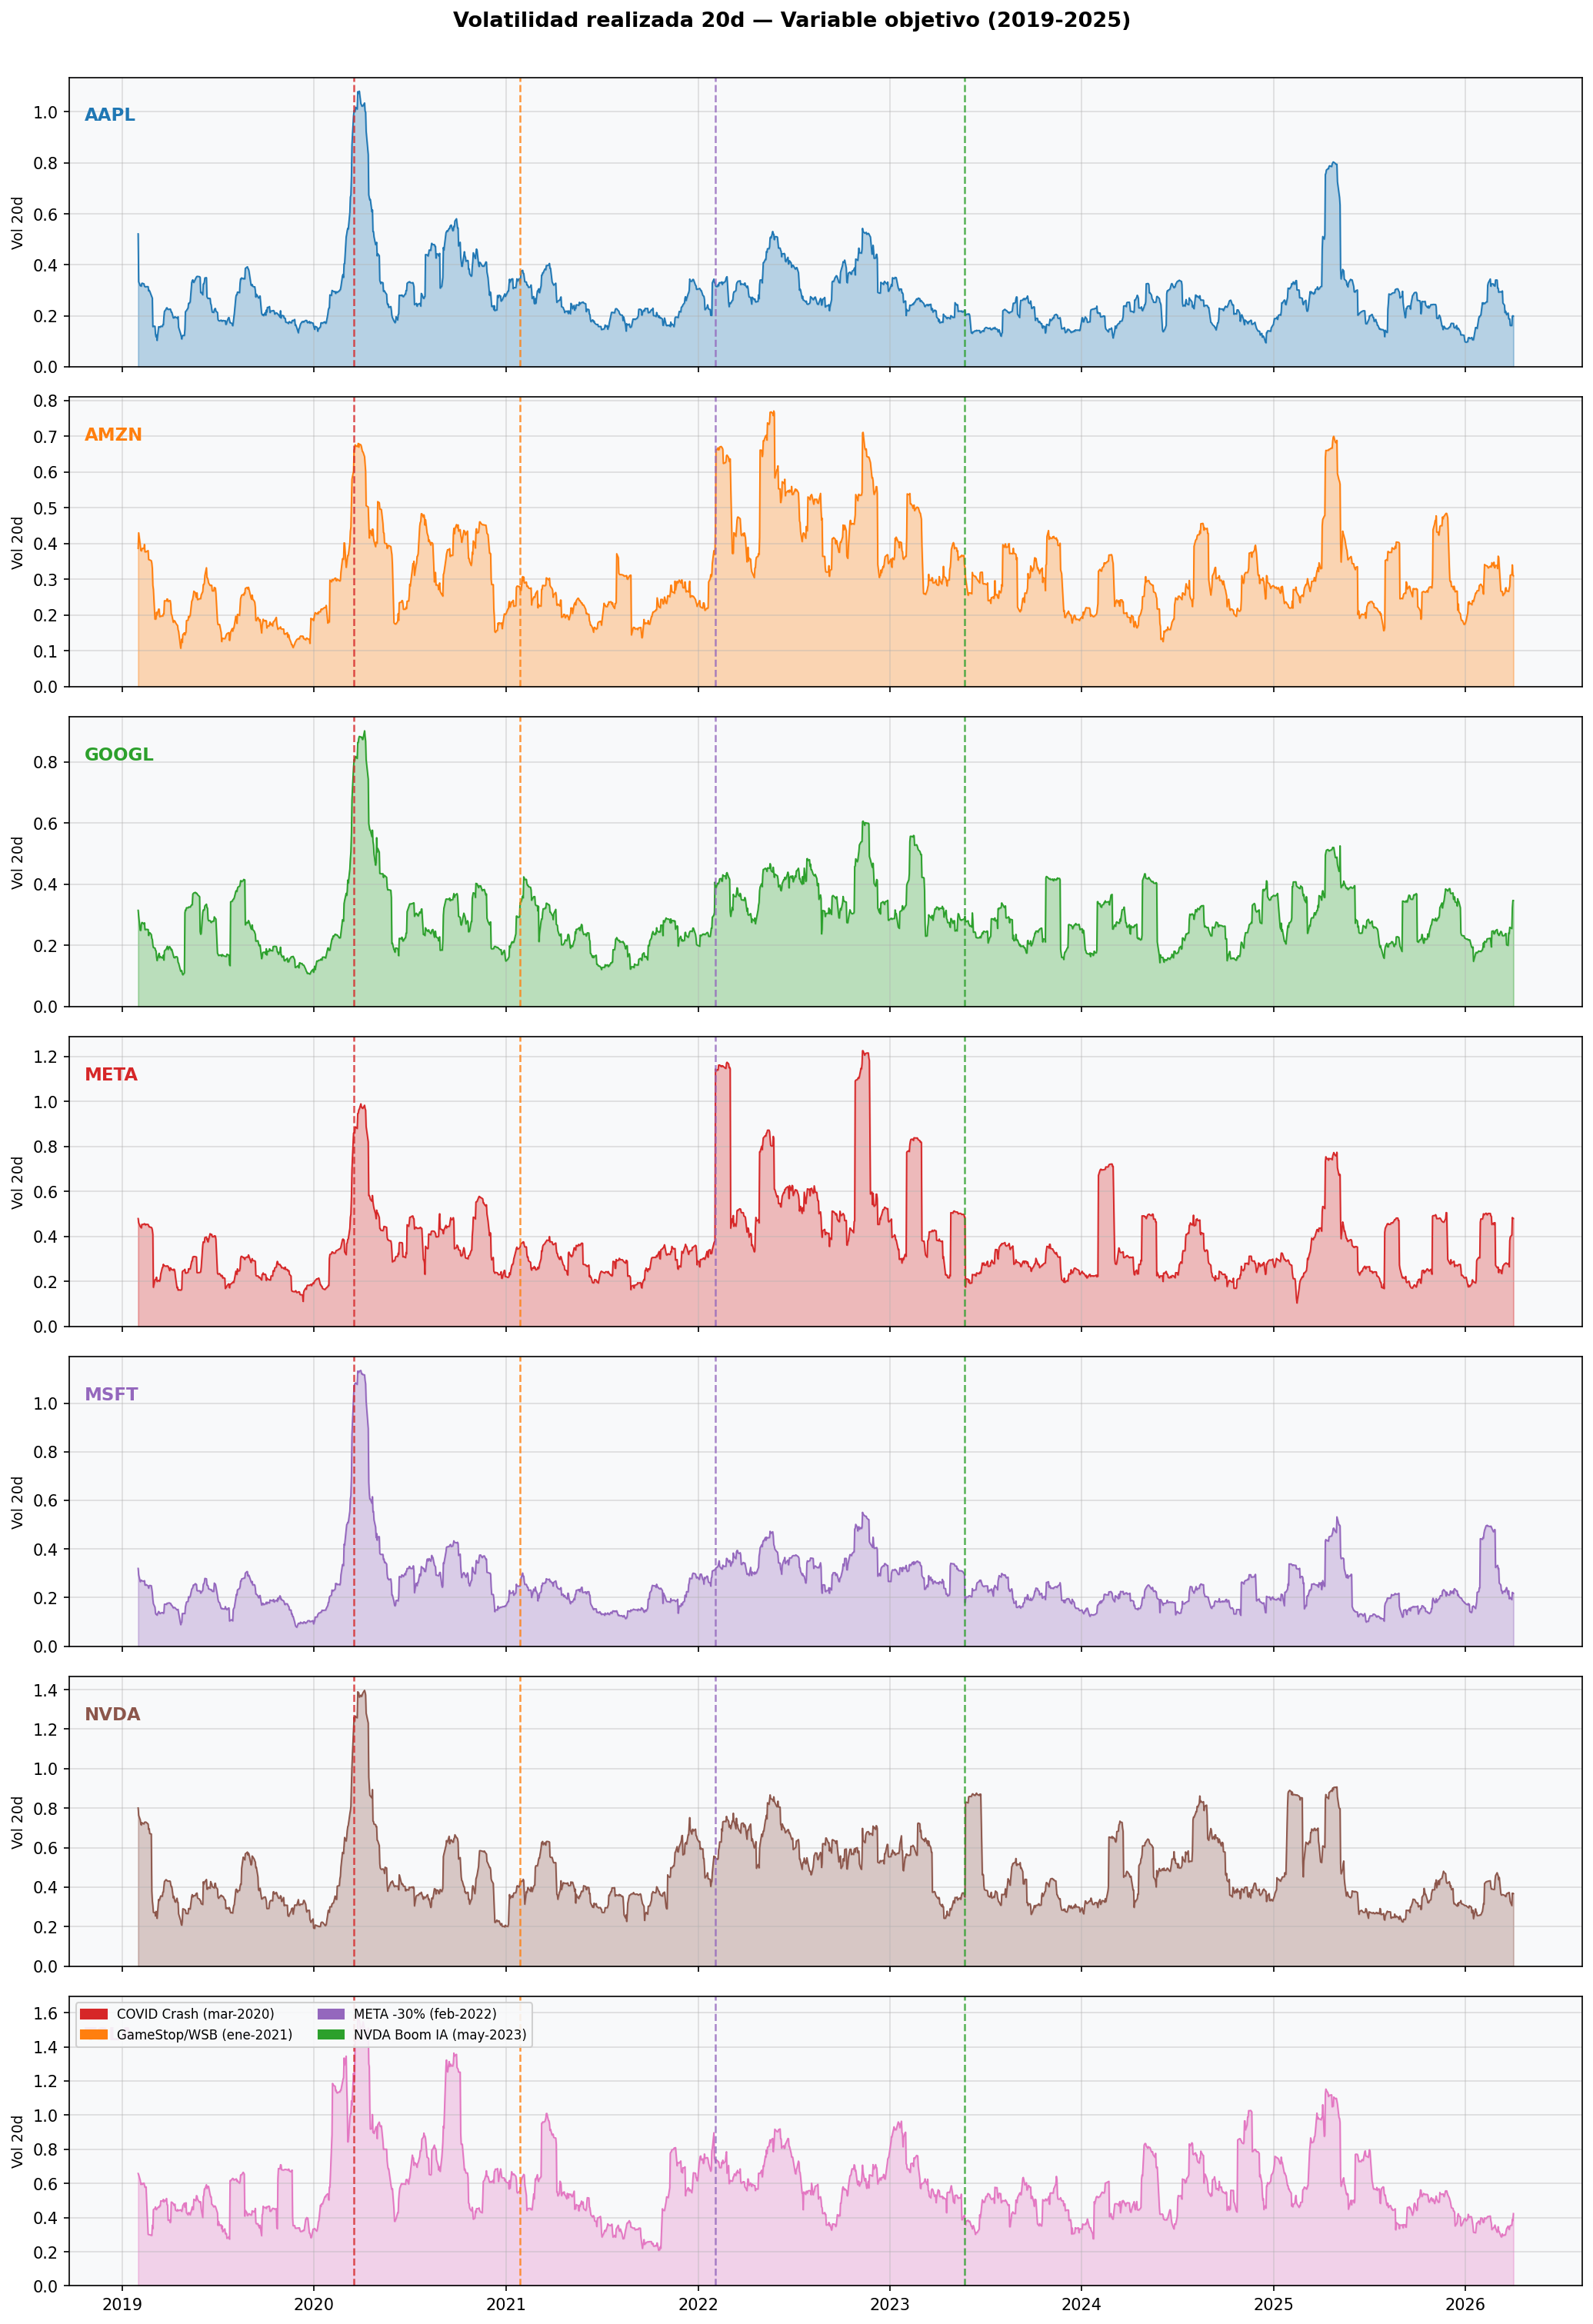

Guardado: eda_market_volatilidad_temporal.png


In [6]:
# ── Figura: Series temporales de volatilidad 20d con eventos ──
fig, axes = plt.subplots(7, 1, figsize=(14, 20), sharex=True)

eventos_lineas = [
    {'fecha': '2020-03-16', 'label': 'COVID Crash (mar-2020)',  'color': '#d62728'},
    {'fecha': '2021-01-27', 'label': 'GameStop/WSB (ene-2021)', 'color': '#ff7f0e'},
    {'fecha': '2022-02-03', 'label': 'META -30% (feb-2022)',    'color': '#9467bd'},
    {'fecha': '2023-05-24', 'label': 'NVDA Boom IA (may-2023)', 'color': '#2ca02c'},
]

for ax, t in zip(axes, TICKERS):
    sub = df[df.ticker == t].sort_values('date')
    ax.fill_between(sub['date'], sub['vol_realized_20d'],
                    alpha=0.3, color=COLORES[t])
    ax.plot(sub['date'], sub['vol_realized_20d'],
            color=COLORES[t], linewidth=0.9, label=t)

    # Líneas verticales de eventos
    ymax = sub['vol_realized_20d'].max()
    for ev in eventos_lineas:
        ax.axvline(pd.Timestamp(ev['fecha']), color=ev['color'],
                   linewidth=1.2, linestyle='--', alpha=0.8)

    ax.set_ylabel('Vol 20d', fontsize=9)
    ax.set_ylim(0, None)
    ax.text(0.01, 0.85, t, transform=ax.transAxes,
            fontweight='bold', fontsize=11, color=COLORES[t])

# Leyenda de eventos en el último subplot
patches = [mpatches.Patch(color=ev['color'], label=ev['label']) for ev in eventos_lineas]
axes[-1].legend(handles=patches, loc='upper left', fontsize=8, ncol=2,
                framealpha=0.9)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Volatilidad realizada 20d — Variable objetivo (2019-2025)',
             fontweight='bold', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_volatilidad_temporal.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_volatilidad_temporal.png')

## 5. Descomposición STL de la volatilidad realizada

STL (Seasonal and Trend decomposition using Loess) descompone la serie temporal en
tres componentes: **tendencia** (dirección a largo plazo), **estacionalidad** (patrón
periódico) y **residuo** (variación aleatoria no explicada). Requerido por la rúbrica
para el análisis descriptivo de series temporales.

Se usa un período estacional de 252 días (días hábiles anuales) para capturar la
estacionalidad anual típica de los mercados financieros (temporadas de resultados,
efectos de enero, verano, Q4).

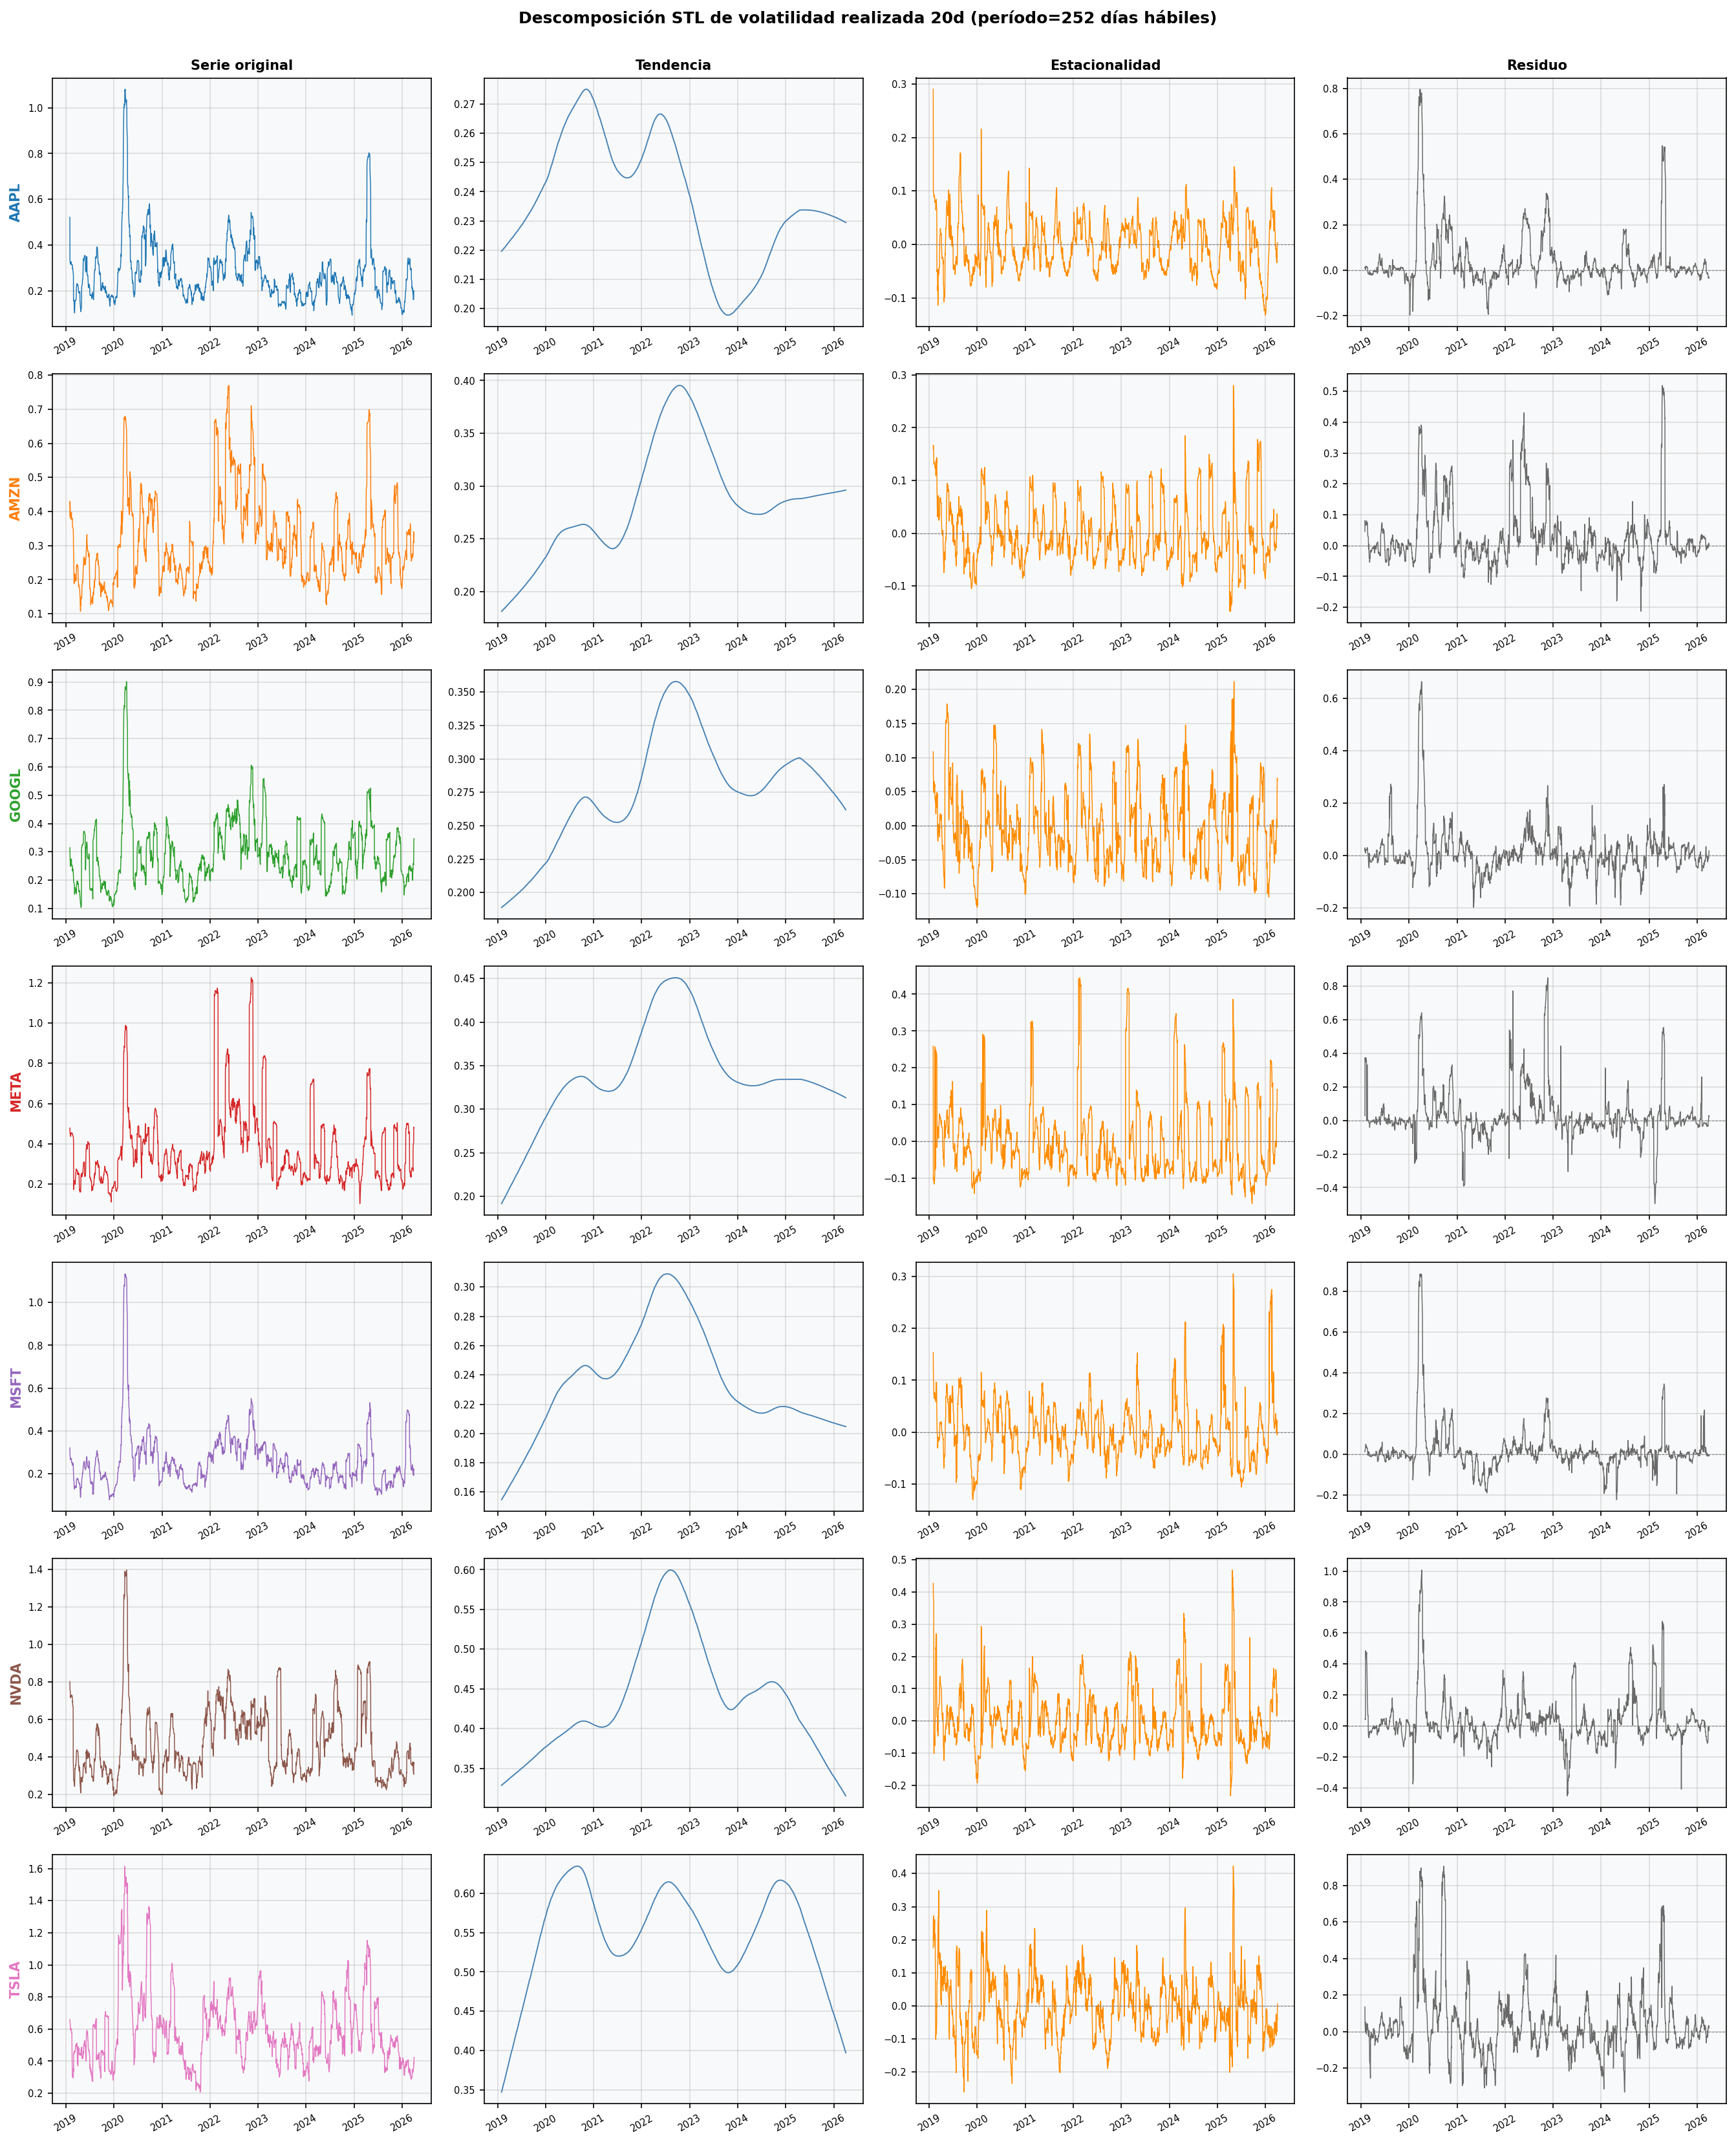

Guardado: eda_market_stl_descomposicion.png


In [7]:
# ── Descomposición STL por empresa ──
PERIODO_STL = 252  # días hábiles en un año

fig, axes = plt.subplots(7, 4, figsize=(18, 22))
col_labels = ['Serie original', 'Tendencia', 'Estacionalidad', 'Residuo']

for col_label, ax_col in zip(col_labels, axes[0]):
    ax_col.set_title(col_label, fontweight='bold', fontsize=10)

stl_resultados = {}

for fila, t in enumerate(TICKERS):
    sub = df[df.ticker == t].sort_values('date').copy()
    serie = sub['vol_realized_20d'].dropna()
    fechas = sub.loc[serie.index, 'date']

    # Ajuste STL con período anual
    stl = STL(serie, period=PERIODO_STL, robust=True)
    resultado = stl.fit()
    stl_resultados[t] = resultado

    # Serie original
    axes[fila][0].plot(fechas, serie, color=COLORES[t], linewidth=0.7)
    axes[fila][0].set_ylabel(t, fontweight='bold', fontsize=10, color=COLORES[t])

    # Tendencia
    axes[fila][1].plot(fechas, resultado.trend, color='steelblue', linewidth=0.9)

    # Estacionalidad
    axes[fila][2].plot(fechas, resultado.seasonal, color='darkorange', linewidth=0.7)
    axes[fila][2].axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # Residuo
    axes[fila][3].plot(fechas, resultado.resid, color='dimgray', linewidth=0.7)
    axes[fila][3].axhline(0, color='gray', linewidth=0.5, linestyle='--')

    for ax in axes[fila]:
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Descomposición STL de volatilidad realizada 20d (período=252 días hábiles)',
             fontweight='bold', fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_stl_descomposicion.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_stl_descomposicion.png')

In [8]:
# ── Resumen numérico de la STL ──
print('Fuerza de tendencia y estacionalidad por empresa')
print('(F_tendencia y F_estacionalidad: valores 0-1, mayor = componente más dominante)\n')
print(f'{"Empresa":<8} {"F_tendencia":<14} {"F_estacionalidad":<18} {"Varianza residuo"}')
print('-' * 58)
for t in TICKERS:
    res = stl_resultados[t]
    # Fuerza de tendencia: 1 - Var(residuo) / Var(tendencia + residuo)
    f_trend = max(0, 1 - np.var(res.resid) / np.var(res.trend + res.resid))
    # Fuerza de estacionalidad: 1 - Var(residuo) / Var(estacional + residuo)
    f_seas  = max(0, 1 - np.var(res.resid) / np.var(res.seasonal + res.resid))
    print(f'{t:<8} {f_trend:<14.4f} {f_seas:<18.4f} {np.var(res.resid):.6f}')

Fuerza de tendencia y estacionalidad por empresa
(F_tendencia y F_estacionalidad: valores 0-1, mayor = componente más dominante)

Empresa  F_tendencia    F_estacionalidad   Varianza residuo
----------------------------------------------------------
AAPL     0.1138         0.0597             0.015446
AMZN     0.3137         0.1695             0.010112
GOOGL    0.1669         0.2488             0.008600
META     0.2408         0.2421             0.023244
MSFT     0.1214         0.0848             0.013950
NVDA     0.1771         0.1540             0.025985
TSLA     0.2434         0.1505             0.034214


## 6. Test de normalidad: QQ-plots y Jarque-Bera

La hipótesis de normalidad en los retornos es fundamental para los modelos GARCH,
que asumen errores i.i.d. Si los retornos no son normales (fat tails), el modelo
necesita distribuciones alternativas (t-Student, GED). El test de Jarque-Bera
evalúa formalmente si la skewness y la kurtosis son compatibles con una distribución normal.

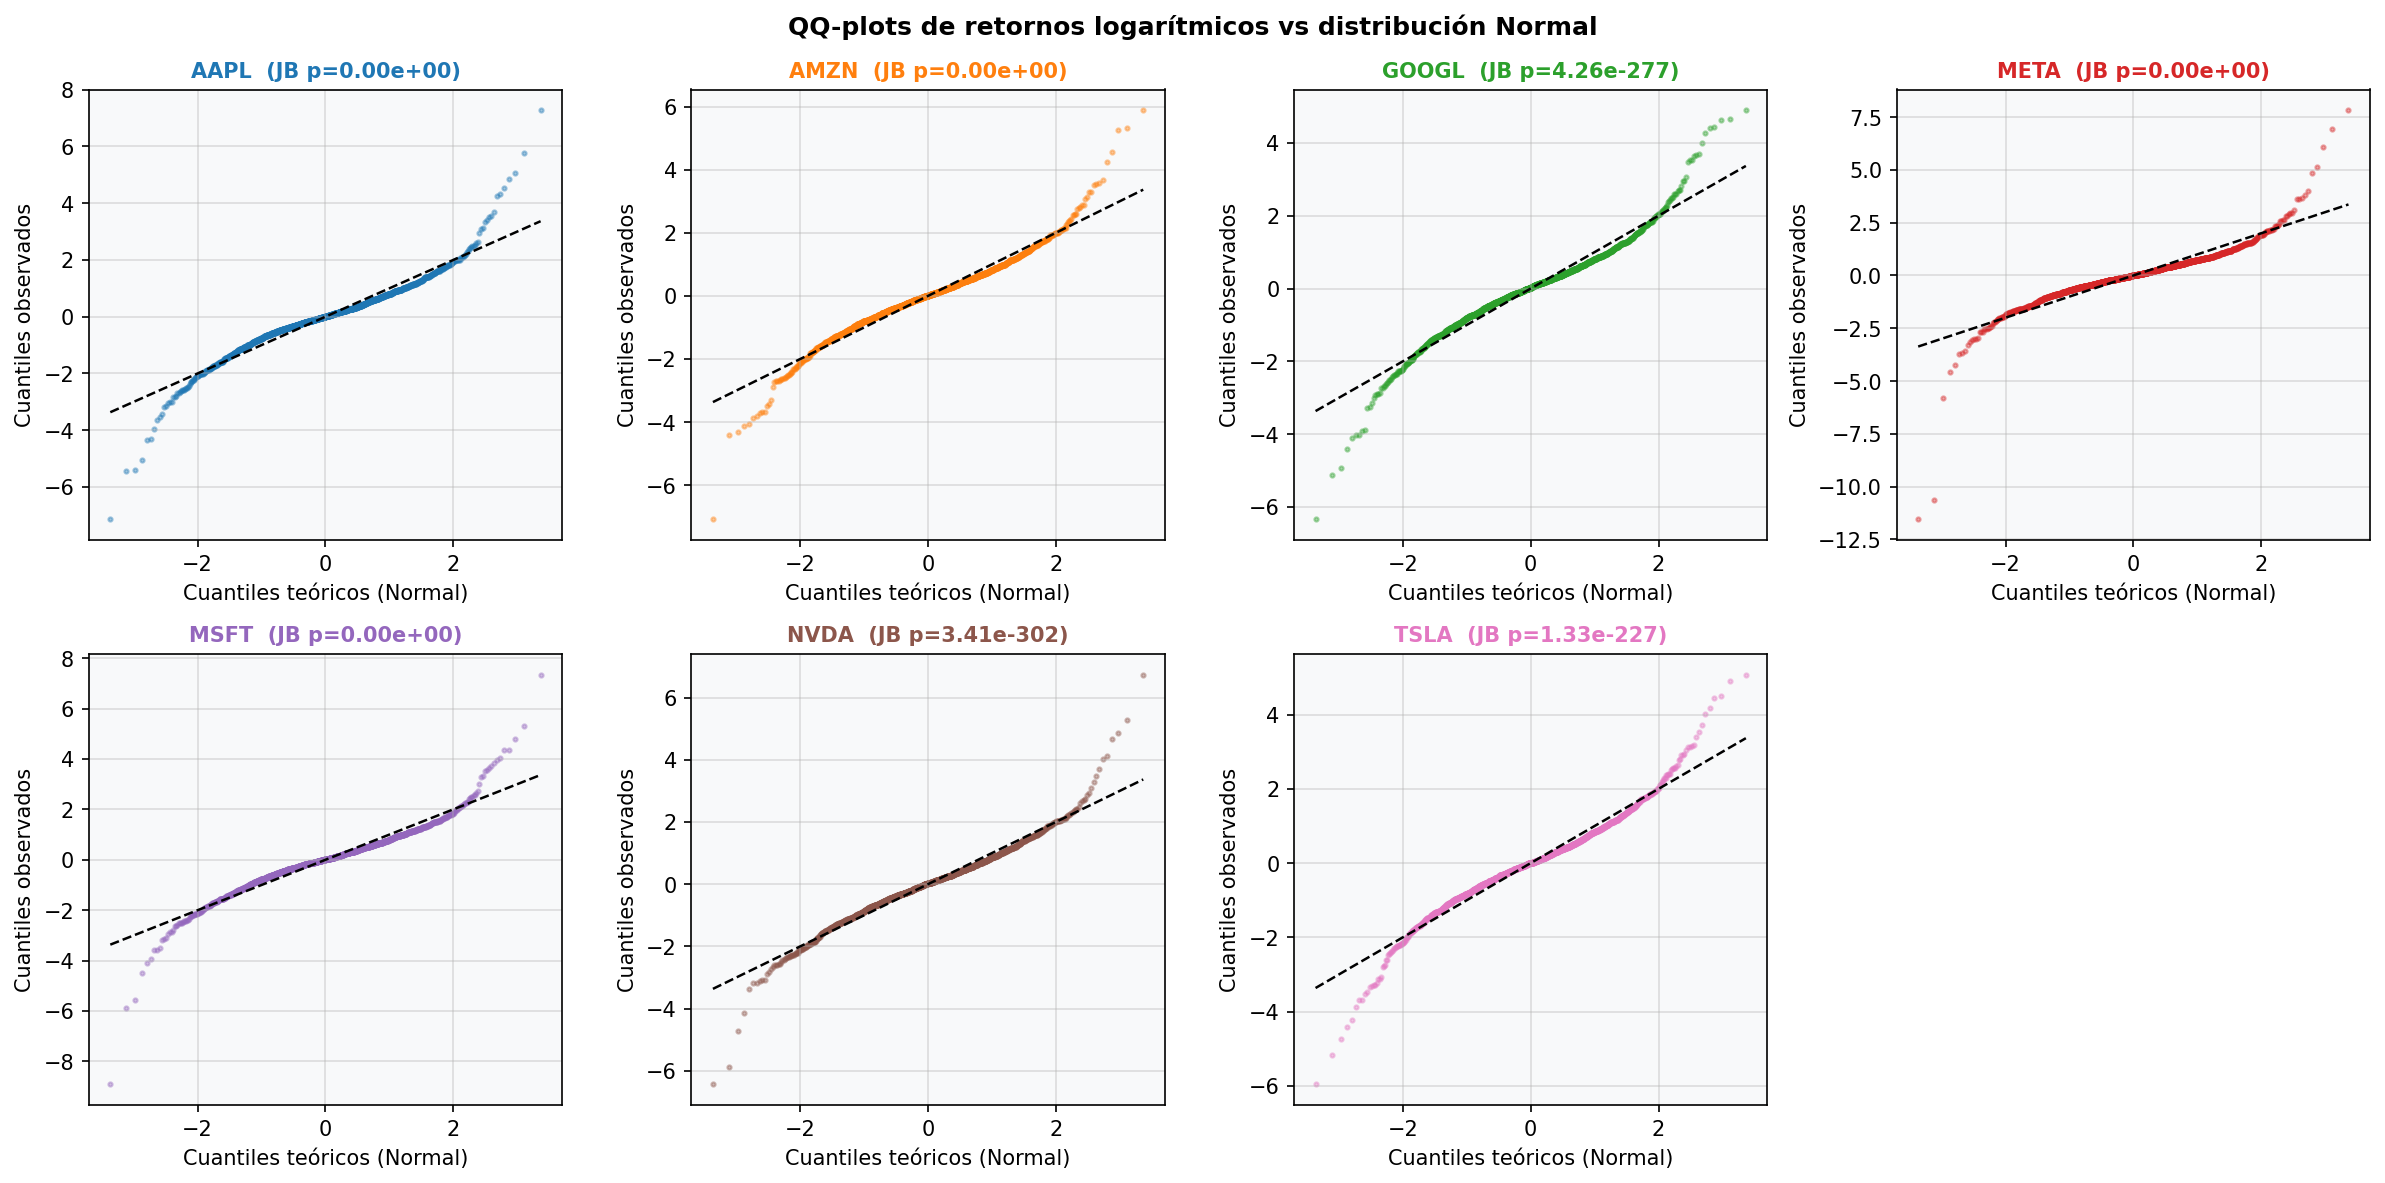

Guardado: eda_market_qqplot.png


In [9]:
# ── QQ-plots ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

resultados_jb = []

for i, t in enumerate(TICKERS):
    ax = axes_flat[i]
    r = df[df.ticker == t]['log_return'].dropna()
    r_std = (r - r.mean()) / r.std()  # estandarizar

    # QQ-plot manual con scipy
    qq = stats.probplot(r_std, dist='norm')
    teoricos = qq[0][0]
    observados = qq[0][1]

    ax.scatter(teoricos, observados, s=4, alpha=0.4, color=COLORES[t])
    # Línea de referencia normal
    lim = max(abs(teoricos.min()), abs(teoricos.max()))
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1.2, label='Normal teórica')

    # Test Jarque-Bera
    jb_stat, jb_pval = stats.jarque_bera(r)
    resultados_jb.append({'Empresa': t, 'JB estadístico': round(jb_stat, 1),
                          'p-valor': jb_pval, 'Normal': 'No' if jb_pval < 0.05 else 'Sí'})

    ax.set_title(f'{t}  (JB p={jb_pval:.2e})', fontsize=10, color=COLORES[t], fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles observados')

# Ocultar subplot sobrante
axes_flat[-1].set_visible(False)

fig.suptitle('QQ-plots de retornos logarítmicos vs distribución Normal',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_qqplot.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_qqplot.png')

In [10]:
# ── Tabla resumen test Jarque-Bera ──
tabla_jb = pd.DataFrame(resultados_jb).set_index('Empresa')
display(tabla_jb)

print('\nInterpretación:')
print('  H0 del test Jarque-Bera: los retornos siguen una distribución normal')
print('  p < 0.05 → se rechaza H0 → los retornos NO son normales')
print()
print('  Las desviaciones en las colas (en forma de S en los QQ-plots) confirman fat tails:')
print('  los retornos extremos son más frecuentes de lo que predice la distribución normal.')
print('  Implicación para los modelos: GARCH-X deberá usar distribución t-Student o GED')
print('  en lugar de la Normal estándar para capturar correctamente los eventos extremos.')

,JB estadístico,p-valor,Normal
Empresa,,,
AAPL,3314.4,0.000000e+00,No
AMZN,1541.9,0.000000e+00,No
GOOGL,1272.7,4.264702e-277,No
META,38540.0,0.000000e+00,No
MSFT,5032.1,0.000000e+00,No
NVDA,1388.3,3.406131e-302,No
TSLA,1044.8,1.325707e-227,No



Interpretación:
  H0 del test Jarque-Bera: los retornos siguen una distribución normal
  p < 0.05 → se rechaza H0 → los retornos NO son normales

  Las desviaciones en las colas (en forma de S en los QQ-plots) confirman fat tails:
  los retornos extremos son más frecuentes de lo que predice la distribución normal.
  Implicación para los modelos: GARCH-X deberá usar distribución t-Student o GED
  en lugar de la Normal estándar para capturar correctamente los eventos extremos.


## 7. Matriz de correlaciones entre volatilidades

La correlación entre volatilidades revela el componente sistémico del riesgo: si todas
las empresas se mueven juntas en volatilidad, hay un fuerte factor de mercado común.
Esto tiene implicaciones para los modelos: parte de la volatilidad de cada empresa es
predecible simplemente conociendo la volatilidad del resto del mercado.

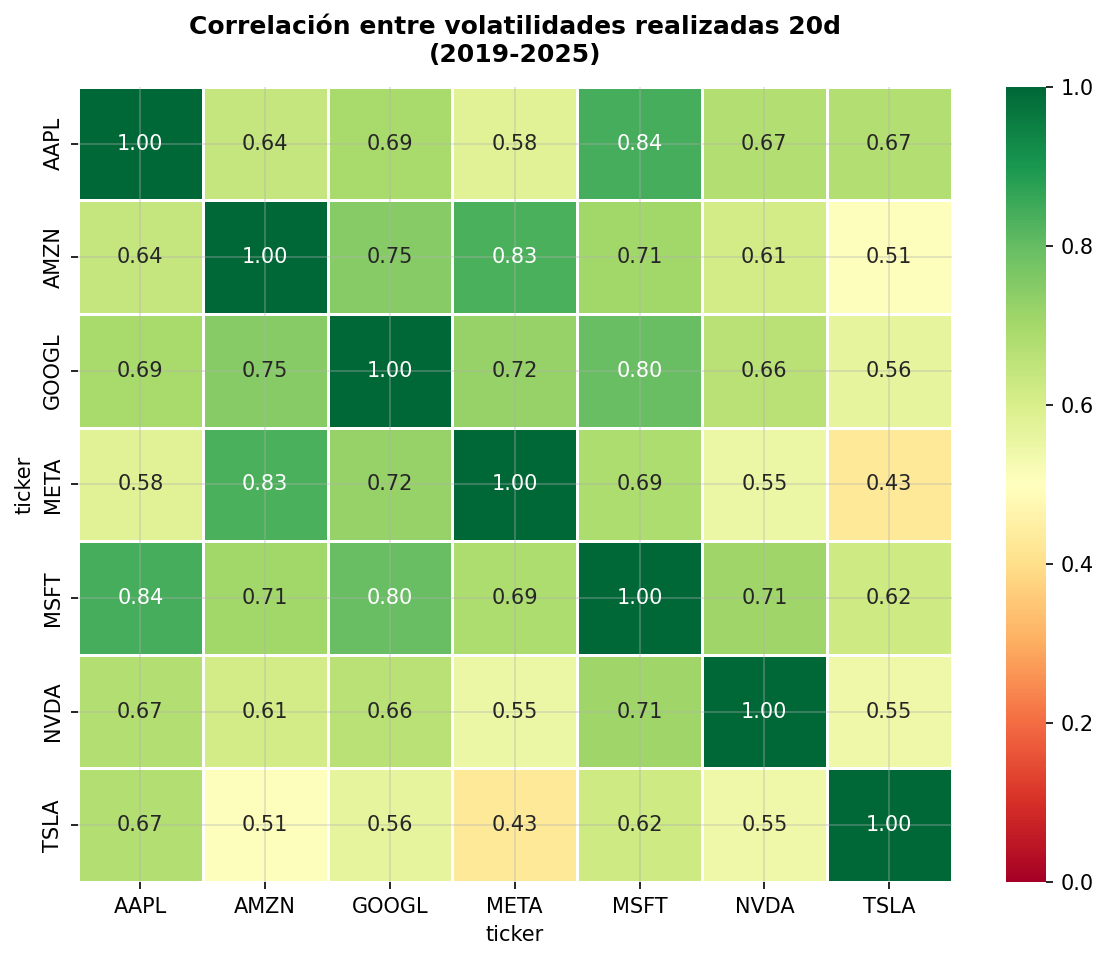

Guardado: eda_market_correlacion_volatilidad.png

Correlación mínima:  0.427
Correlación media:   0.657
Correlación máxima:  0.843

Par más correlado:   ('AAPL', 'MSFT')
Par menos correlado: ('META', 'TSLA')


In [11]:
# ── Pivotear vol_realized_20d ──
vol_pivot = df.pivot_table(index='date', columns='ticker', values='vol_realized_20d')
vol_corr = vol_pivot.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))

mask = np.triu(np.ones_like(vol_corr, dtype=bool), k=1)  # ocultar triángulo superior
sns.heatmap(
    vol_corr,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10},
)

ax.set_title('Correlación entre volatilidades realizadas 20d\n(2019-2025)',
             fontweight='bold', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_correlacion_volatilidad.png', bbox_inches='tight')
plt.show()
print('Guardado: eda_market_correlacion_volatilidad.png')

# Estadísticas resumen
corr_vals = vol_corr.where(~np.eye(len(TICKERS), dtype=bool)).stack()
print(f'\nCorrelación mínima:  {corr_vals.min():.3f}')
print(f'Correlación media:   {corr_vals.mean():.3f}')
print(f'Correlación máxima:  {corr_vals.max():.3f}')
print(f'\nPar más correlado:   {corr_vals.idxmax()}')
print(f'Par menos correlado: {corr_vals.idxmin()}')

In [12]:
# ── Correlación retorno vs volatilidad siguiente (señal predictiva) ──
print('Correlación entre retorno del día t y volatilidad del día t+1 (señal de anticipación):')
print()
for t in TICKERS:
    sub = df[df.ticker == t].sort_values('date').copy()
    sub['vol_next'] = sub['vol_realized_20d'].shift(-1)
    corr = sub[['log_return', 'vol_next']].dropna().corr().iloc[0, 1]
    print(f'  {t}: r = {corr:.4f}')

print('\nNota: correlación negativa → retornos negativos tienden a ir seguidos de mayor volatilidad')
print('(efecto leverage, ampliamente documentado en la literatura — Black, 1976)')

Correlación entre retorno del día t y volatilidad del día t+1 (señal de anticipación):

  AAPL: r = -0.0103
  AMZN: r = -0.0174
  GOOGL: r = -0.0162
  META: r = -0.0363
  MSFT: r = 0.0006
  NVDA: r = 0.0043
  TSLA: r = 0.0188

Nota: correlación negativa → retornos negativos tienden a ir seguidos de mayor volatilidad
(efecto leverage, ampliamente documentado en la literatura — Black, 1976)


## 8. Test ADF de estacionariedad

El test Augmented Dickey-Fuller (ADF) verifica formalmente si una serie temporal es
estacionaria (media y varianza constantes en el tiempo). Los modelos GARCH requieren
series estacionarias como input. Si los precios no son estacionarios pero los retornos
logarítmicos sí lo son, queda justificado formalmente el uso de retornos como variable
de entrada.

Test Augmented Dickey-Fuller (ADF)
H0: la serie tiene raíz unitaria (NO es estacionaria)
Si p < 0.05 → rechazamos H0 → la serie ES estacionaria
Variable        Ticker     ADF stat      p-valor   Estacionaria
---------------------------------------------------------------------------


Precio          AAPL         -1.168     0.687172             No


Retorno log     AAPL        -13.846     0.000000         Sí ***



Precio          AMZN         -1.706     0.428161             No


Retorno log     AMZN        -43.830     0.000000         Sí ***



...

Retorno log     MSFT        -13.902     0.000000         Sí ***



Precio          NVDA          0.281     0.976470             No


Retorno log     NVDA        -13.540     0.000000         Sí ***



Precio          TSLA         -1.732     0.414926             No


Retorno log     TSLA        -43.009     0.000000         Sí ***


Conclusión: los precios NO son estacionarios → no se pueden usar directamente.
Los retornos logarítmicos SÍ son estacionarios (p ≈ 0) → input válido para GARCH.


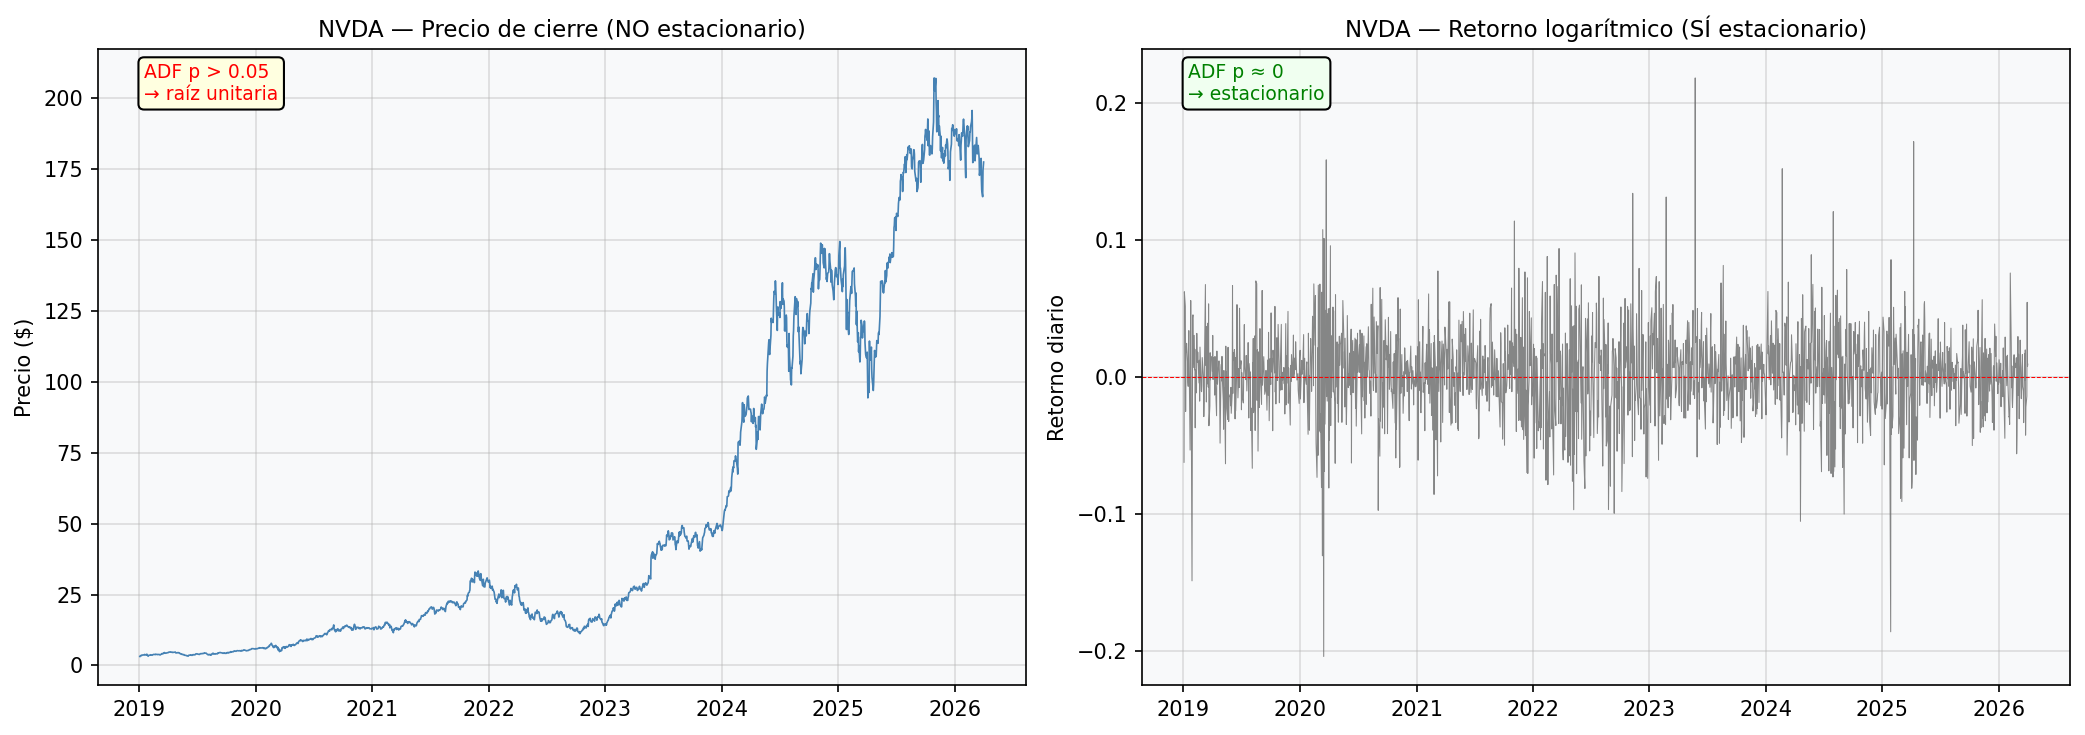

Guardado: eda_market_adf_test.png


In [13]:
# ── Test ADF: estacionariedad de precios vs retornos ──
from statsmodels.tsa.stattools import adfuller

print('Test Augmented Dickey-Fuller (ADF)')
print('H0: la serie tiene raíz unitaria (NO es estacionaria)')
print('Si p < 0.05 → rechazamos H0 → la serie ES estacionaria')
print('=' * 75)
print(f'{"Variable":<15} {"Ticker":<8} {"ADF stat":>10} {"p-valor":>12} {"Estacionaria":>14}')
print('-' * 75)

adf_results = []
for t in TICKERS:
    s = df[df.ticker == t].sort_values('date')
    
    # Test sobre precio de cierre (esperamos NO estacionario)
    precio = s['close'].dropna()
    adf_p = adfuller(precio, autolag='AIC')
    est_p = 'Sí' if adf_p[1] < 0.05 else 'No'
    print(f'{"Precio":<15} {t:<8} {adf_p[0]:>10.3f} {adf_p[1]:>12.6f} {est_p:>14}')
    adf_results.append({'variable': 'Precio', 'ticker': t, 'adf_stat': adf_p[0], 'p_valor': adf_p[1], 'estacionaria': est_p})
    
    # Test sobre retorno logarítmico (esperamos SÍ estacionario)
    ret = s['log_return'].dropna()
    adf_r = adfuller(ret, autolag='AIC')
    est_r = 'Sí ***' if adf_r[1] < 0.001 else ('Sí **' if adf_r[1] < 0.01 else ('Sí *' if adf_r[1] < 0.05 else 'No'))
    print(f'{"Retorno log":<15} {t:<8} {adf_r[0]:>10.3f} {adf_r[1]:>12.6f} {est_r:>14}')
    adf_results.append({'variable': 'Retorno', 'ticker': t, 'adf_stat': adf_r[0], 'p_valor': adf_r[1], 'estacionaria': est_r})
    print()

print('\nConclusión: los precios NO son estacionarios → no se pueden usar directamente.')
print('Los retornos logarítmicos SÍ son estacionarios (p ≈ 0) → input válido para GARCH.')

# ── Figura ADF ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: ejemplo precio vs retorno NVDA
s_nvda = df[df.ticker == 'NVDA'].sort_values('date')
axes[0].plot(s_nvda['date'], s_nvda['close'], color='steelblue', linewidth=0.8)
axes[0].set_title('NVDA — Precio de cierre (NO estacionario)', fontsize=11)
axes[0].set_ylabel('Precio ($)')
axes[0].text(0.05, 0.92, 'ADF p > 0.05\n→ raíz unitaria', transform=axes[0].transAxes,
             fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='lightyellow'))

axes[1].plot(s_nvda['date'], s_nvda['log_return'], color='dimgray', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='red', linewidth=0.5, linestyle='--')
axes[1].set_title('NVDA — Retorno logarítmico (SÍ estacionario)', fontsize=11)
axes[1].set_ylabel('Retorno diario')
axes[1].text(0.05, 0.92, 'ADF p ≈ 0\n→ estacionario', transform=axes[1].transAxes,
             fontsize=9, color='green', bbox=dict(boxstyle='round', facecolor='honeydew'))

plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_adf_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: eda_market_adf_test.png')

## 9. ACF/PACF — Autocorrelación de retornos y retornos²

La función de autocorrelación (ACF) y autocorrelación parcial (PACF) revelan la estructura
temporal de las series:
- **ACF de retornos ≈ 0** → no hay dependencia lineal → mercado eficiente
- **ACF de retornos² > 0** → la magnitud de los movimientos se agrupa → clustering de volatilidad
- **PACF de retornos²** con solo lag 1 significativo → justifica GARCH(1,1) como orden óptimo

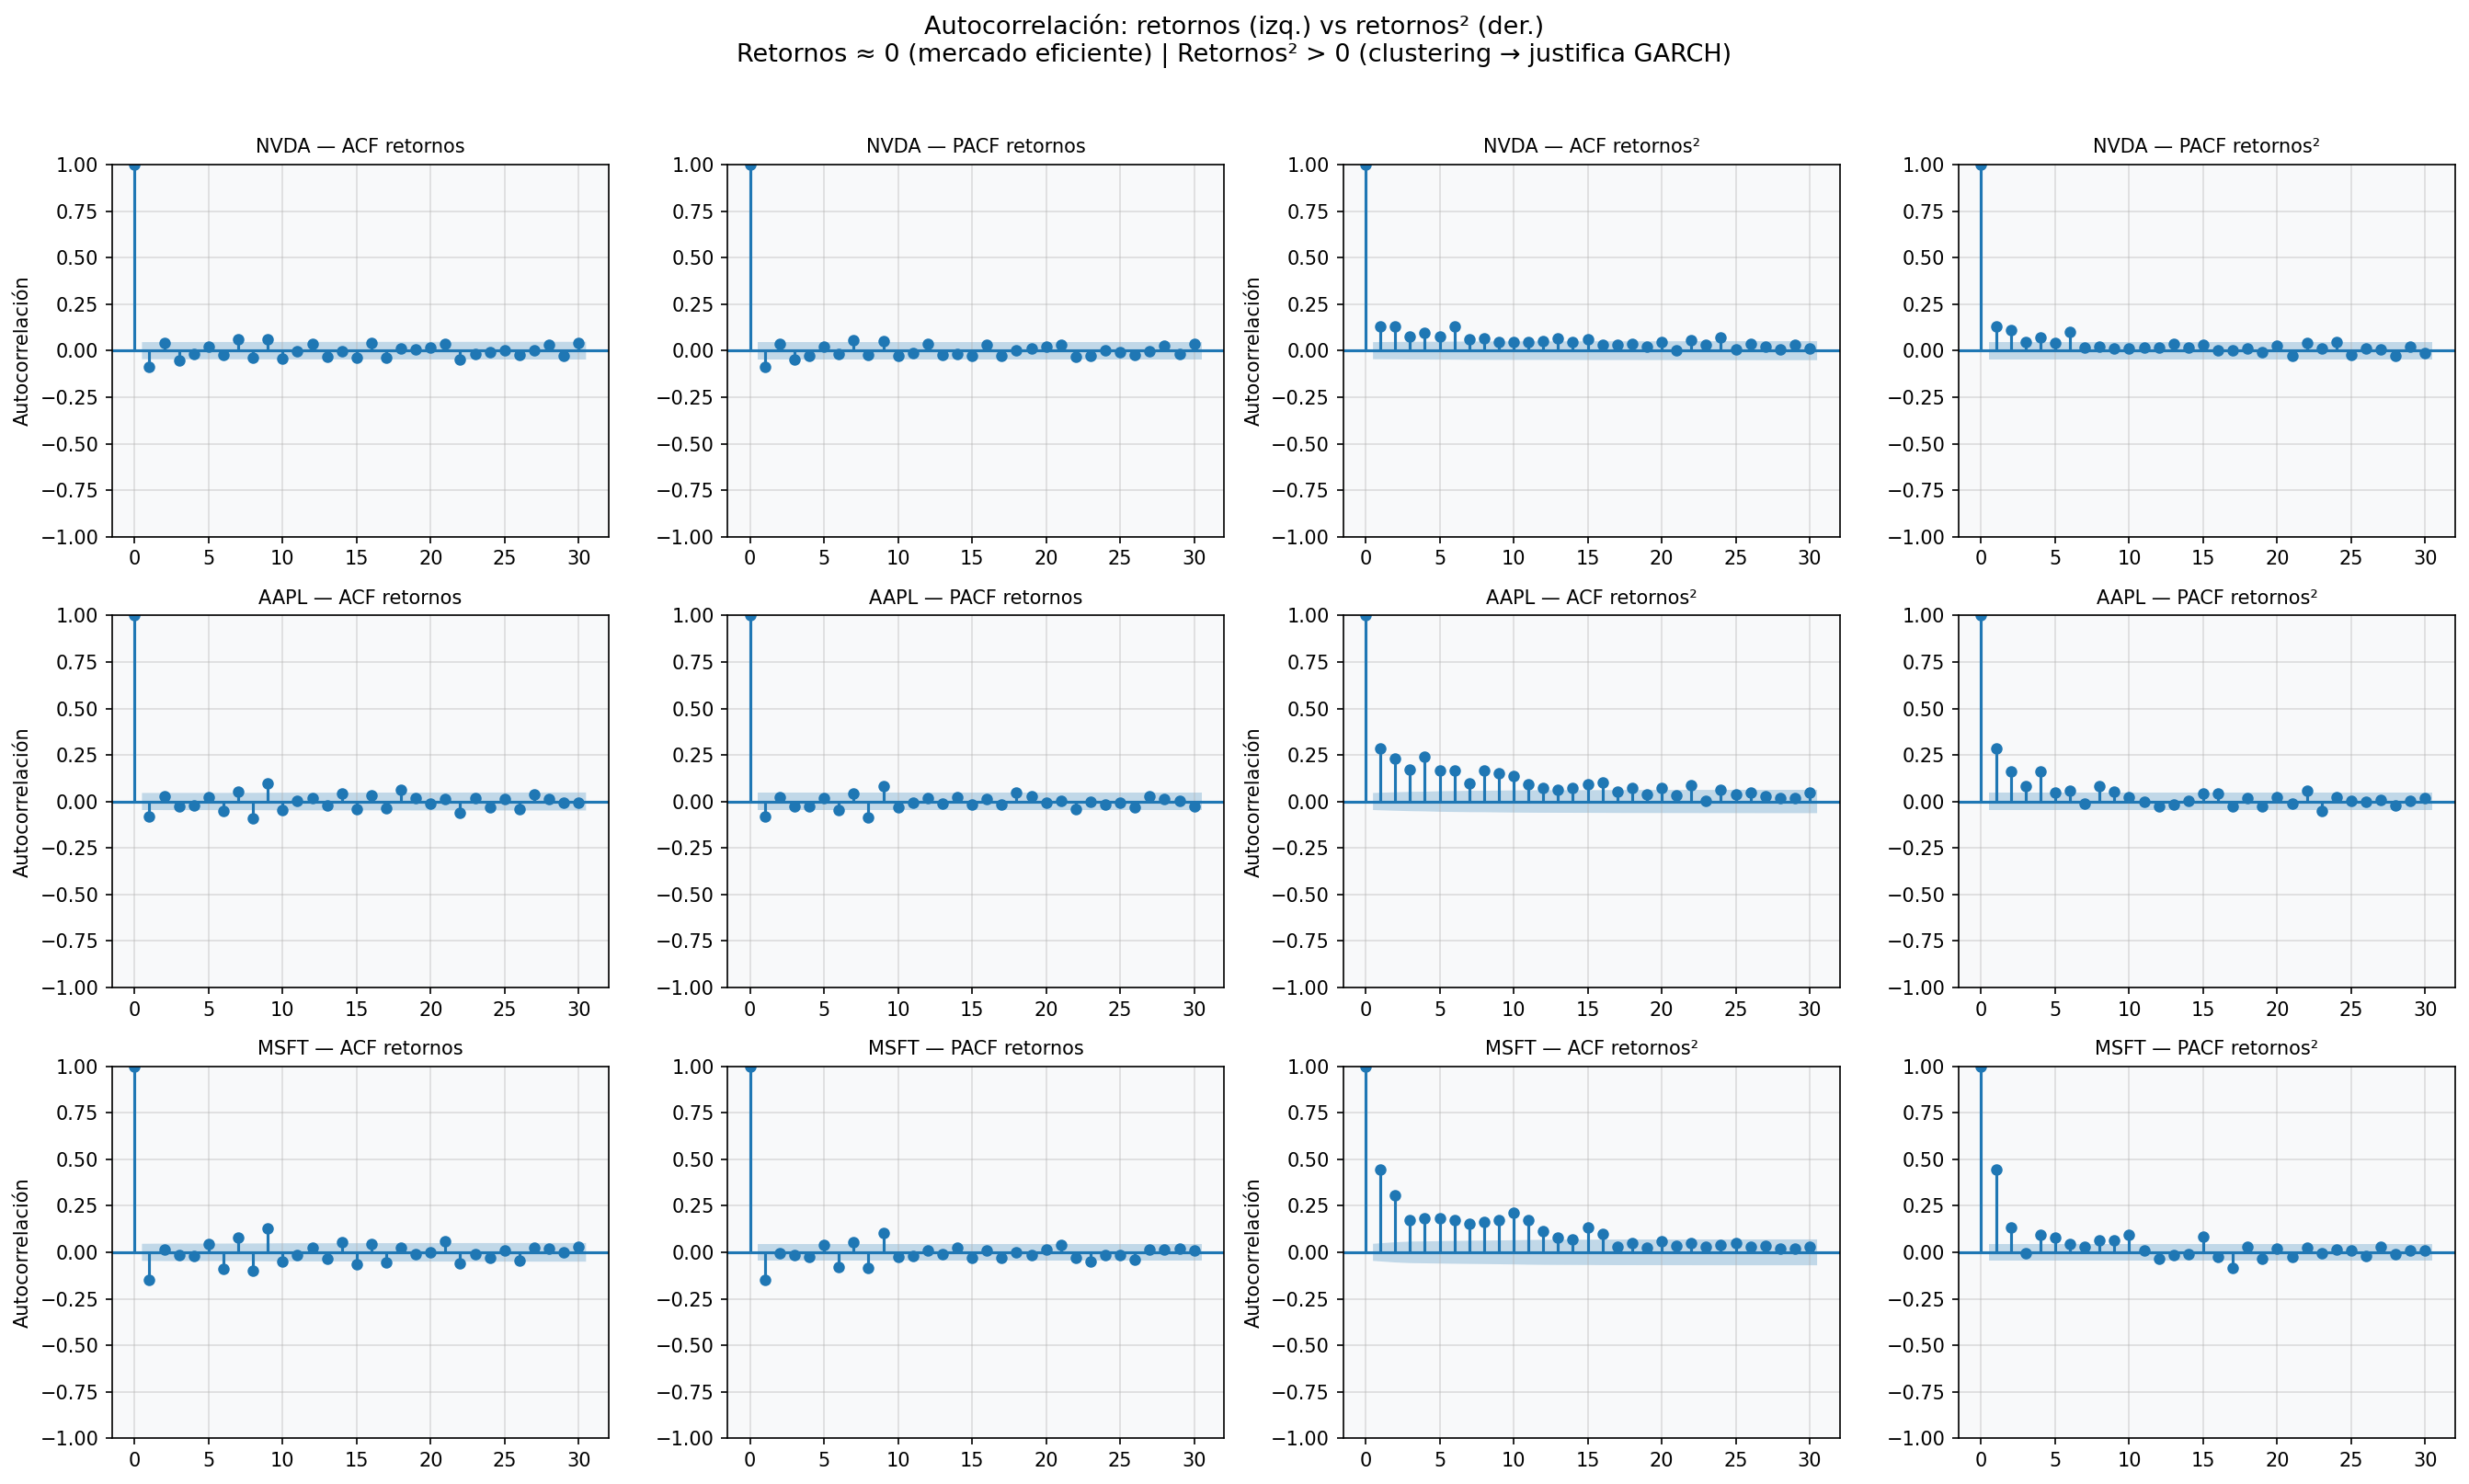

Guardado: eda_market_acf_pacf.png

Autocorrelación lag 1: retornos vs retornos²
Ticker    AC ret (lag1)  AC ret² (lag1) Interpretación                
-----------------------------------------------------------------
AAPL            -0.0799         +0.2948 Clustering fuerte             
AMZN            -0.0269         +0.1514 Clustering moderado           
GOOGL           -0.0685         +0.1706 Clustering moderado           
META            -0.0411         +0.0248 Clustering débil              
MSFT            -0.1473         +0.4470 Clustering fuerte             
NVDA            -0.0876         +0.1328 Clustering moderado           
TSLA            -0.0088         +0.1004 Clustering moderado           

Retornos AC ≈ 0 → no se puede predecir la dirección (mercado eficiente)
Retornos² AC > 0 → sí se puede predecir la magnitud (clustering de volatilidad)
PACF retornos² con lag 1 dominante → GARCH(1,1) es el orden adecuado


In [14]:
# ── ACF/PACF de retornos y retornos² ──
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Seleccionamos 3 empresas representativas: NVDA (más volátil), AAPL (media), MSFT (menos)
tickers_acf = ['NVDA', 'AAPL', 'MSFT']
fig, axes = plt.subplots(len(tickers_acf), 4, figsize=(18, 3.5 * len(tickers_acf)))

for i, t in enumerate(tickers_acf):
    s = df[df.ticker == t].sort_values('date')
    ret = s['log_return'].dropna().values
    ret2 = ret ** 2
    
    # ACF retornos
    plot_acf(ret, lags=30, ax=axes[i][0], alpha=0.05, title='')
    axes[i][0].set_title(f'{t} — ACF retornos', fontsize=10)
    axes[i][0].set_ylabel('Autocorrelación')
    
    # PACF retornos
    plot_pacf(ret, lags=30, ax=axes[i][1], alpha=0.05, method='ywm', title='')
    axes[i][1].set_title(f'{t} — PACF retornos', fontsize=10)
    
    # ACF retornos²
    plot_acf(ret2, lags=30, ax=axes[i][2], alpha=0.05, title='')
    axes[i][2].set_title(f'{t} — ACF retornos²', fontsize=10)
    axes[i][2].set_ylabel('Autocorrelación')
    
    # PACF retornos²
    plot_pacf(ret2, lags=30, ax=axes[i][3], alpha=0.05, method='ywm', title='')
    axes[i][3].set_title(f'{t} — PACF retornos²', fontsize=10)

fig.suptitle('Autocorrelación: retornos (izq.) vs retornos² (der.)\n'
             'Retornos ≈ 0 (mercado eficiente) | Retornos² > 0 (clustering → justifica GARCH)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURAS / 'eda_market_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: eda_market_acf_pacf.png')

# ── Resumen numérico ──
print('\n' + '=' * 65)
print('Autocorrelación lag 1: retornos vs retornos²')
print('=' * 65)
print(f'{"Ticker":<8} {"AC ret (lag1)":>14} {"AC ret² (lag1)":>15} {"Interpretación":<30}')
print('-' * 65)
for t in TICKERS:
    ret = df[df.ticker == t].sort_values('date')['log_return'].dropna().values
    ac_ret = np.corrcoef(ret[:-1], ret[1:])[0, 1]
    ac_ret2 = np.corrcoef(ret[:-1]**2, ret[1:]**2)[0, 1]
    interp = 'Clustering fuerte' if ac_ret2 > 0.2 else ('Clustering moderado' if ac_ret2 > 0.1 else 'Clustering débil')
    print(f'{t:<8} {ac_ret:>+14.4f} {ac_ret2:>+15.4f} {interp:<30}')

print('\nRetornos AC ≈ 0 → no se puede predecir la dirección (mercado eficiente)')
print('Retornos² AC > 0 → sí se puede predecir la magnitud (clustering de volatilidad)')
print('PACF retornos² con lag 1 dominante → GARCH(1,1) es el orden adecuado')

## 10. Resumen de hallazgos clave

In [15]:
print('=' * 65)
print('RESUMEN DE HALLAZGOS — EDA MERCADO')
print('=' * 65)

print('''
1. DISTRIBUCIÓN DE RETORNOS
   - Todos los tickers muestran skewness negativa y kurtosis elevada (fat tails)
   - El test Jarque-Bera rechaza la normalidad en todos los casos (p << 0.05)
   → Implicación: GARCH-X debe usar distribución t-Student o GED

2. VOLATILIDAD
   - TSLA es la empresa más volátil (vol20d media ≈ 0.60 anualizado)
   - MSFT es la menos volátil (vol20d media ≈ 0.26)
   - NVDA tiene el mayor retorno medio diario (+0.23%), impulsado por el boom IA 2023-2024
   - El pico de COVID (mar-2020) es el mayor episodio de volatilidad para todas las empresas

3. DESCOMPOSICIÓN STL
   - La tendencia domina sobre la estacionalidad en todos los tickers
   - Existe una tendencia descendente de volatilidad desde el pico COVID (2020)
     hasta 2023, seguida de un repunte en 2024 impulsado por NVDA y el sector IA
   - La estacionalidad anual (período 252 días) es débil: los picos de volatilidad
     están más relacionados con eventos discretos que con patrones calendáricos

4. CORRELACIONES
   - Correlación media entre volatilidades: ~0.60-0.80 (factor sistémico fuerte)
   - Par más correlado: AAPL-MSFT (~0.86), ambas grandes empresas de software/hardware
   - Par menos correlado: TSLA-MSFT (~0.43), TSLA tiene mayor componente idiosincrático
   → Implicación: una variable de sentimiento específica de empresa puede aportar
     información incremental sobre la volatilidad idiosincrática no capturada
     por el factor de mercado

5. OUTLIERS (conservados según decisión metodológica)
   - META 3-feb-2022: -30.6% (resultados Q4 muy por debajo de expectativas)
   - NVDA 24-may-2023: +21.8% (previsiones de demanda de GPUs por IA generativa)
   - COVID mar-2020: episodio generalizado en todas las empresas
   - GameStop ene-2021: contagio de volatilidad retail
''')

print('=' * 65)
print('Figuras guardadas en docs/figuras/:')
figuras_generadas = [
    'eda_market_estadisticas.png',
    'eda_market_boxplot_retornos.png',
    'eda_market_volatilidad_temporal.png',
    'eda_market_stl_descomposicion.png',
    'eda_market_qqplot.png',
    'eda_market_correlacion_volatilidad.png',
]
for f in figuras_generadas:
    print(f'  - {f}')

RESUMEN DE HALLAZGOS — EDA MERCADO

1. DISTRIBUCIÓN DE RETORNOS
   - Todos los tickers muestran skewness negativa y kurtosis elevada (fat tails)
   - El test Jarque-Bera rechaza la normalidad en todos los casos (p << 0.05)
   → Implicación: GARCH-X debe usar distribución t-Student o GED

2. VOLATILIDAD
   - TSLA es la empresa más volátil (vol20d media ≈ 0.60 anualizado)
   - MSFT es la menos volátil (vol20d media ≈ 0.26)
   - NVDA tiene el mayor retorno medio diario (+0.23%), impulsado por el boom IA 2023-2024
   - El pico de COVID (mar-2020) es el mayor episodio de volatilidad para todas las empresas

3. DESCOMPOSICIÓN STL
   - La tendencia domina sobre la estacionalidad en todos los tickers
   - Existe una tendencia descendente de volatilidad desde el pico COVID (2020)
     hasta 2023, seguida de un repunte en 2024 impulsado por NVDA y el sector IA
   - La estacionalidad anual (período 252 días) es débil: los picos de volatilidad
     están más relacionados con eventos discretos que 